In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
from matplotlib.colors import LogNorm
import plotly.express as px
import plotly.io as pio

In [2]:
df = pd.read_csv('owid-covid-data.csv',encoding='latin1')
# paises = ["Brazil",'Germany','United States','South Africa','India']
# df = df[df['location'].isin(paises)]

In [3]:
df.shape

(429435, 67)

In [4]:
df.head(10)

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
5,AFG,Asia,Afghanistan,2020-01-10,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
6,AFG,Asia,Afghanistan,2020-01-11,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
7,AFG,Asia,Afghanistan,2020-01-12,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
8,AFG,Asia,Afghanistan,2020-01-13,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
9,AFG,Asia,Afghanistan,2020-01-14,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [5]:
df.describe(include='all')

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
count,429435,402910,429435,429435,4.118040e+05,4.101590e+05,4.089290e+05,4.118040e+05,410608.000000,409378.000000,...,243817.000000,161741.000000,290689.000000,390299.000000,319127.000000,4.294350e+05,1.341100e+04,13411.000000,13411.000000,13411.000000
unique,255,6,255,1688,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,OWID_HIC,Africa,High-income countries,2021-10-22,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3026,95419,3026,261,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,7.365292e+06,8.017360e+03,8.041026e+03,8.125957e+04,71.852139,72.060828,...,33.097758,50.649390,3.106895,73.702098,0.722178,1.520336e+08,5.604765e+04,9.766431,10.925353,1772.666404
std,NaN,NaN,NaN,NaN,4.477582e+07,2.296649e+05,8.661611e+04,4.411901e+05,1368.322990,513.636565,...,13.853952,31.905236,2.549168,7.387914,0.149237,6.975408e+08,1.568691e+05,12.040658,24.560706,1991.892770
min,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,...,7.700000,1.190000,0.100000,53.280000,0.390000,4.700000e+01,-3.772610e+04,-44.230000,-95.920000,-2936.450000
25%,NaN,NaN,NaN,NaN,6.280750e+03,0.000000e+00,0.000000e+00,4.300000e+01,0.000000,0.000000,...,22.600000,20.860000,1.300000,69.500000,0.600000,5.237980e+05,1.765000e+02,2.060000,-1.500000,116.875000
50%,NaN,NaN,NaN,NaN,6.365300e+04,0.000000e+00,1.200000e+01,7.990000e+02,0.000000,0.000000,...,33.100000,49.540000,2.500000,75.050000,0.740000,6.336393e+06,6.815200e+03,8.130000,5.660000,1270.800000
75%,NaN,NaN,NaN,NaN,7.582720e+05,0.000000e+00,3.132900e+02,9.574000e+03,0.000000,3.140000,...,41.500000,82.500000,4.210000,79.460000,0.830000,3.296952e+07,3.912804e+04,15.160000,15.575000,2883.025000


In [6]:
df.tail()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
429430,ZWE,Africa,Zimbabwe,2024-07-31,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429431,ZWE,Africa,Zimbabwe,2024-08-01,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429432,ZWE,Africa,Zimbabwe,2024-08-02,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429433,ZWE,Africa,Zimbabwe,2024-08-03,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN
429434,ZWE,Africa,Zimbabwe,2024-08-04,266386.0,0.0,0.0,5740.0,0.0,0.0,...,30.7,36.79,1.7,61.49,0.57,16320539,NaN,NaN,NaN,NaN


In [67]:
df.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed',
       ...
       'days_since_vax_start', 'vax_speed_raw', 'vax_speed_7d',
       'vax_speed_30d', 'doses_needed_70', 'days_to_70pct', 'score',
       'income_category', 'density_category', 'age_category'],
      dtype='object', length=102)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 429435 entries, 0 to 429434
Columns: 102 entries, iso_code to age_category
dtypes: UInt32(1), bool(3), category(3), datetime64[ns](2), float64(81), int32(2), int64(3), object(7)
memory usage: 331.9+ MB


In [69]:
pd.set_option('display.max_rows', None)
df.isnull().sum()

iso_code                                           0
continent                                      26525
location                                           0
date                                               0
total_cases                                    17631
new_cases                                      19276
new_cases_smoothed                             20506
total_deaths                                   17631
new_deaths                                     18827
new_deaths_smoothed                            20057
total_cases_per_million                        17631
new_cases_per_million                          19276
new_cases_smoothed_per_million                 20506
total_deaths_per_million                       17631
new_deaths_per_million                         18827
new_deaths_smoothed_per_million                20057
reproduction_rate                             244618
icu_patients                                  390319
icu_patients_per_million                      

In [70]:
df['date'] = pd.to_datetime(df['date'])

In [71]:
(df.isna().mean()*100).sort_values(ascending = False)

weekly_icu_admissions_per_million             97.440125
weekly_icu_admissions                         97.440125
excess_mortality_cumulative_per_million       96.877059
excess_mortality                              96.877059
excess_mortality_cumulative                   96.877059
excess_mortality_cumulative_absolute          96.877059
weekly_hosp_admissions_per_million            94.295528
weekly_hosp_admissions                        94.295528
icu_patients                                  90.891287
icu_patients_per_million                      90.891287
days_to_70pct                                 90.853331
vax_speed_30d                                 90.835167
hosp_patients_per_million                     90.532677
hosp_patients                                 90.532677
vax_speed_7d                                  88.294853
total_boosters_per_hundred                    87.518484
total_boosters                                87.518484
vax_speed_raw                                 84

In [72]:
df['continent'].isna().value_counts()

continent
False    402910
True      26525
Name: count, dtype: int64

In [ ]:
df['date'].min(), df['date'].max()

In [ ]:
df_countries = df[df['continent'].notna()].copy()

In [ ]:
df_agg = df[df["continent"].isna()].copy()

In [ ]:
df.isnull().sum()

In [17]:
df_num = df.select_dtypes(include='number')

colunas_com_negativos = df_num.columns[(df_num < 0).any()]
colunas_com_negativos

Index(['reproduction_rate', 'excess_mortality_cumulative_absolute',
       'excess_mortality_cumulative', 'excess_mortality',
       'excess_mortality_cumulative_per_million'],
      dtype='object')

In [18]:
df["year"] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.day_name()
df['week_of_year'] = df['date'].dt.isocalendar().week
df['month_year'] = df['date'].dt.strftime('%b/%Y')
df['pandemic_week'] = (df["date"] - pd.to_datetime('2020-01-01')).dt.days//7


In [19]:
X =pd.to_datetime('2020-12-01')
Y = pd.to_datetime('2021-07-01')
condicoes = [
    df["date"] < X,
    (df["date"] >= X) & (df["date"] < Y),
    df["date"] >= Y
]

fases = ["Pre-vaccination", "Initial vaccination", "Advanced vaccination"]

df["covid_phase"] = np.select(condicoes, fases,default="Unknown")

In [20]:
df['case_fatality_rate'] = (df['total_deaths']/df["total_cases"])*100

In [21]:
df['daily_growth_pct'] = (
    df['new_cases'] /
    df.groupby('location')['total_cases'].shift(1)
) * 100

df.loc[df['daily_growth_pct'] < 0, 'daily_growth_pct'] = np.nan


In [22]:
df['new_cases_ma7'] = (
    df
    .groupby('location')['new_cases']
    .rolling(window=7)
    .mean()
    .reset_index(level=0, drop=True)
)

df['new_deaths_ma7'] = (
    df
    .groupby('location')['new_deaths']
    .rolling(window=7)
    .mean()
    .reset_index(level=0, drop=True)
)


In [23]:
df['weekly_cases'] = (df.groupby(['location','pandemic_week'])['new_cases'].transform('sum'))
df['weekly_cases_prev'] = df.groupby('location')['weekly_cases'].shift(1)
df['weekly_growth_rate'] = ( (df['weekly_cases'] - df['weekly_cases_prev'] ) / df['weekly_cases_prev'])
df.loc[df['weekly_growth_rate'] < -1, 'weekly_growth_rate'] = np.nan

In [24]:
df['log_cases'] = np.log1p(df['total_cases'])

In [25]:
# 1. SMOOTH CASES
df['cases_smooth'] = df.groupby('location')['new_cases_smoothed'].transform(
    lambda x: x.rolling(window=7, center=True, min_periods=1).mean()
)

# 2. IDENTIFY LOCAL PEAKS
df['is_local_peak'] = df.groupby('location')['cases_smooth'].transform(
    lambda x: (
        (x > x.shift(1)) & 
        (x > x.shift(-1)) &
        (x > x.shift(2)) &
        (x > x.shift(-2)) &
        (x > 0)
    )
)

# 3. FILTER SIGNIFICANT PEAKS
df['max_cases'] = df.groupby('location')['cases_smooth'].transform('max')
df['min_significant'] = df['max_cases'] * 0.15

df['is_significant_peak'] = (
    df['is_local_peak'] & 
    (df['cases_smooth'] >= df['min_significant'])
)

# 4. FILTER BY TIME DISTANCE
def filter_peaks_by_distance(group, min_days=45):
    """Keep only the highest peak within a time window"""
    peaks = group[group['is_significant_peak']].copy()
    
    if len(peaks) == 0:
        return pd.Series(False, index=group.index)
    
    filtered_peaks = []
    last_peak_date = None
    
    for idx, row in peaks.iterrows():
        if last_peak_date is None:
            days_diff = min_days
        else:
            days_diff = (row['date'] - last_peak_date).days
        
        if days_diff >= min_days:
            filtered_peaks.append(idx)
            last_peak_date = row['date']
        else:
            if len(filtered_peaks) > 0:
                last_idx = filtered_peaks[-1]
                if row['cases_smooth'] > group.loc[last_idx, 'cases_smooth']:
                    filtered_peaks[-1] = idx
                    last_peak_date = row['date']
    
    result = pd.Series(False, index=group.index)
    result.loc[filtered_peaks] = True
    return result

df['is_real_peak'] = df.groupby('location', group_keys=False).apply(
    filter_peaks_by_distance, include_groups=False
).values

# 5. IDENTIFY WAVES
df['wave_id'] = df.groupby('location')['is_real_peak'].cumsum()

# 6. ADDITIONAL METRICS
df['days_since_last_peak'] = df.groupby('location', group_keys=False).apply(
    lambda g: (g['date'] - g.loc[g['is_real_peak'], 'date'].reindex(g.index, method='ffill')).dt.days,
    include_groups=False
).values

df['peak_intensity'] = df.groupby(['location', 'wave_id'])['cases_smooth'].transform('max')

# Display peaks
print("\n📊 DETECTED PEAKS:")
print(df[df['is_real_peak']][['location', 'date', 'cases_smooth', 'wave_id']].head(20))

# Summary by location
print("\n📈 SUMMARY BY COUNTRY:")
summary = df[df['is_real_peak']].groupby('location').agg({
    'wave_id': 'max',
    'cases_smooth': 'max',
    'date': ['min', 'max']
}).round(2)
summary.columns = ['total_waves', 'max_peak', 'first_wave', 'last_wave']
print(summary.head(10))


📊 DETECTED PEAKS:
         location       date  cases_smooth  wave_id
157   Afghanistan 2020-06-10        729.71        1
542   Afghanistan 2021-06-30       1759.14        2
773   Afghanistan 2022-02-16        634.29        3
1228  Afghanistan 2023-05-17        283.29        4
1873       Africa 2020-07-22      17980.57        1
1999       Africa 2020-11-25      13606.14        2
2048       Africa 2021-01-13      31138.86        3
2146       Africa 2021-04-21      12017.00        4
2258       Africa 2021-08-11      42466.00        5
2412       Africa 2022-01-12      45144.86        6
2461       Africa 2022-03-02      19000.43        7
2538       Africa 2022-05-18       9688.71        8
2608       Africa 2022-07-27       8058.43        9
3694      Albania 2020-12-16        794.43        1
3757      Albania 2021-02-17       1107.57        2
3967      Albania 2021-09-15        882.29        3
4030      Albania 2021-11-17        574.14        4
4100      Albania 2022-01-26       2200.71   

In [26]:
df_br = df[df["location"] == 'Brazil']

In [27]:
start_vax = (df[df["total_vaccinations"] > 0].groupby("location")["date"].min())

df["vax_start_date"] = df["location"].map(start_vax)

df["days_since_vax_start"] = (df["date"] - df["vax_start_date"]).dt.days


In [28]:
df = df.sort_values(["location", "date"])

df["vax_speed_raw"] = (df.groupby("location")["total_vaccinations"].diff())
df["vax_speed_raw"] = df["vax_speed_raw"].clip(lower=0)
df["vax_speed_7d"] = (df.groupby("location")["vax_speed_raw"].transform(lambda x: x.rolling(7).mean()))


In [29]:
population = df.groupby("location")["population"].first()
df["vax_speed_30d"] = (df.groupby('location')['vax_speed_raw'].rolling(30).mean().reset_index(level=0, drop= True))

df["doses_needed_70"] = 0.7 * df["population"] - df["total_vaccinations"]

df["doses_needed_70"] = df["doses_needed_70"].clip(lower=0)

df["days_to_70pct"] = ( df["doses_needed_70"] / df["vax_speed_30d"])

df["days_to_70pct"] = df["days_to_70pct"].replace([np.inf, -np.inf], np.nan)


In [30]:
df_countries.groupby('location')['total_cases_per_million'].max().rank().sort_values(ascending=False).dropna()
df_agg.groupby('location')['total_cases_per_million'].max().rank().sort_values(ascending=False).dropna()

location
European Union (27)              12.0
High-income countries            11.0
Europe                           10.0
Oceania                           9.0
North America                     8.0
South America                     7.0
World                             6.0
Upper-middle-income countries     5.0
Asia                              4.0
Lower-middle-income countries     3.0
Africa                            2.0
Low-income countries              1.0
Name: total_cases_per_million, dtype: float64

In [31]:
df_countries.groupby("location")['total_deaths_per_million'].max().rank().sort_values(ascending=False).dropna()

location
Peru                                234.0
Bulgaria                            233.0
North Macedonia                     232.0
Bosnia and Herzegovina              231.0
Hungary                             230.0
Croatia                             229.0
Slovenia                            228.0
Georgia                             227.0
Montenegro                          226.0
Czechia                             225.0
Moldova                             224.0
Latvia                              223.0
Slovakia                            222.0
Greece                              221.0
San Marino                          220.0
Romania                             219.0
United States                       218.0
Lithuania                           217.0
United Kingdom                      216.0
Brazil                              215.0
Italy                               214.0
Chile                               213.0
Martinique                          212.0
Poland                   

In [32]:
df.groupby('location')['people_fully_vaccinated_per_hundred'].max().reset_index()

,location,people_fully_vaccinated_per_hundred
0,Afghanistan,44.67
1,Africa,32.41
2,Albania,45.01
3,Algeria,14.43
4,American Samoa,NaN
5,Andorra,67.01
6,Angola,27.00
7,Anguilla,65.38
8,Antigua and Barbuda,66.53
9,Argentina,76.69


In [33]:
# score = (1 - taxa_mortalidade) * taxa_vacinação
case_fatality_norm = df['case_fatality_rate'] / 100
taxa_vacination_norm = df["people_fully_vaccinated_per_hundred"] / 100

df['score'] = (1 - case_fatality_norm) * taxa_vacination_norm
df_countries['score'] = (1 - case_fatality_norm) * taxa_vacination_norm
df_countries.groupby("location")["score"].mean().reset_index().sort_values(by="score", ascending=False).dropna()
df_agg['score'] = (1 - case_fatality_norm) * taxa_vacination_norm
df_agg.groupby("location")["score"].mean().reset_index().sort_values(by="score", ascending=False).dropna()

,location,score
9,South America,0.565086
1,Asia,0.551765
2,Europe,0.545628
7,North America,0.536495
8,Oceania,0.504915
11,World,0.484522
0,Africa,0.173665


In [34]:
df_countries.groupby('location')['gdp_per_capita'].mean().reset_index().dropna().sort_values(by='gdp_per_capita',ascending=False)
df_agg.groupby('location')['gdp_per_capita'].mean().reset_index().dropna().sort_values(by='gdp_per_capita',ascending=False)

,location,gdp_per_capita
11,World,15469.21


In [35]:
bins = [0, 1135, 4465, 13845, df['gdp_per_capita'].max()]
labels = ['Low income', 'Lower-middle income', 'Upper-middle income', 'High income']

df['income_category'] = pd.cut(
    df['gdp_per_capita'],
    bins=bins,
    labels=labels
)


In [36]:
df['density_category'] = pd.cut(
    df['population_density'],
    bins=[0, 50, 200, 500, 1000, df['population_density'].max()],
    labels=['Low Density', 'Medium Density', 'High Density', 'Very High Density', 'Extremely Dense']
)


In [37]:
df['age_category'] = pd.cut(
    df['median_age'],
    bins=[0, 25, 35, 45, np.inf],
    labels=[
        'Young Population',
        'Adult Population',
        'Aging Population',
        'Elderly Population'
    ]
)


In [38]:
df['age_category'].value_counts()

age_category
Young Population      111498
Adult Population      108847
Aging Population      102597
Elderly Population     11721
Name: count, dtype: int64

In [39]:
##EDA
df_world = df_agg[df_agg['location'] == 'World']
df_world.groupby('location')['total_cases'].max().reset_index()

,location,total_cases
0,World,775866783.0


In [40]:
df_world.groupby('location')['total_deaths'].max().reset_index()

,location,total_deaths
0,World,7057132.0


In [41]:
df_world.groupby('location')['people_fully_vaccinated'].max().reset_index()

,location,people_fully_vaccinated
0,World,5.177943e+09


In [42]:
df_world.loc[
    df_world['new_cases_smoothed'].idxmax(),
    ['date', 'new_cases_smoothed']
]

date                  2022-12-25 00:00:00
new_cases_smoothed              6319461.0
Name: 423814, dtype: object

In [43]:
df_world.loc[df_world['new_deaths_smoothed'].idxmax(),
    ['date','new_deaths_smoothed']
]

date                   2021-01-24 00:00:00
new_deaths_smoothed                14817.0
Name: 423114, dtype: object

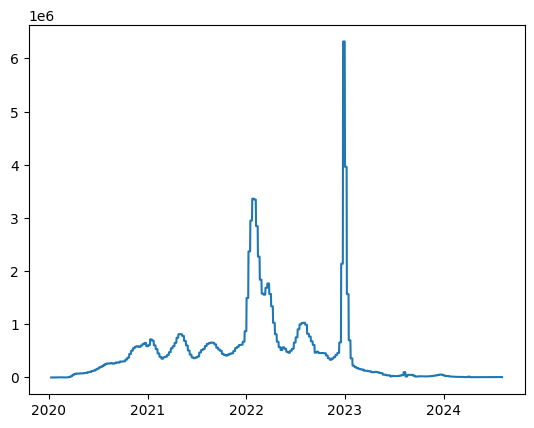

In [44]:
plt.plot(df_world['date'], df_world['new_cases_smoothed'])
plt.show()


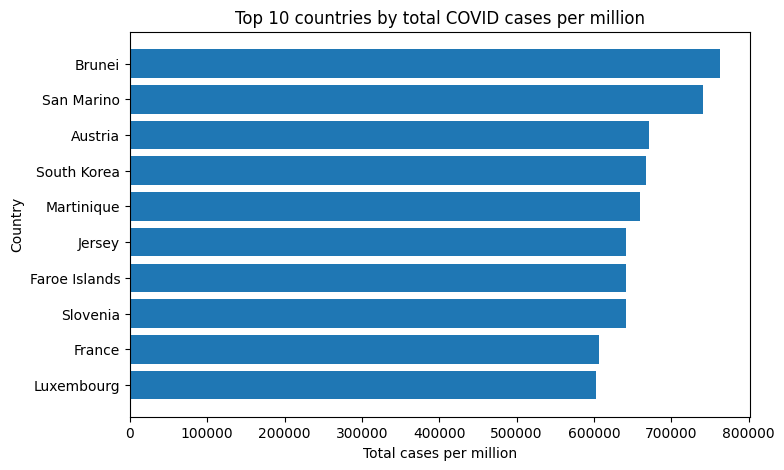

In [45]:
# Ranking de Casos

top10_cases = df_countries.groupby('location')['total_cases_per_million'].max().reset_index().sort_values(by='total_cases_per_million',ascending=False).head(10)
top10_totalcases = df_countries.groupby('location')['total_cases'].max().reset_index().sort_values(by='total_cases',ascending=False).head(10)

plt.figure(figsize=(8, 5))

plt.barh(
    top10_cases["location"],
    top10_cases["total_cases_per_million"]
)

plt.xlabel("Total cases per million")
plt.ylabel("Country")
plt.title("Top 10 countries by total COVID cases per million")

# opcional: inverter ordem para o maior ficar no topo
plt.gca().invert_yaxis()

plt.show()


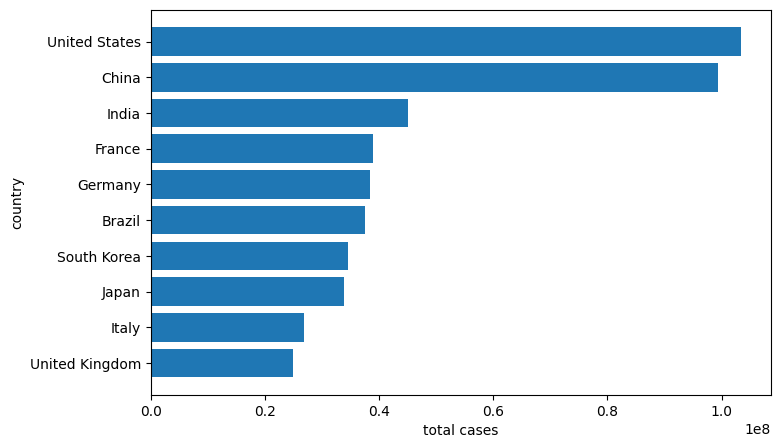

In [46]:
plt.figure(figsize=(8,5))

plt.barh(
    top10_totalcases['location'],
    top10_totalcases['total_cases']
)

plt.xlabel('total cases')
plt.ylabel('country')

plt.gca().invert_yaxis()

plt.show()

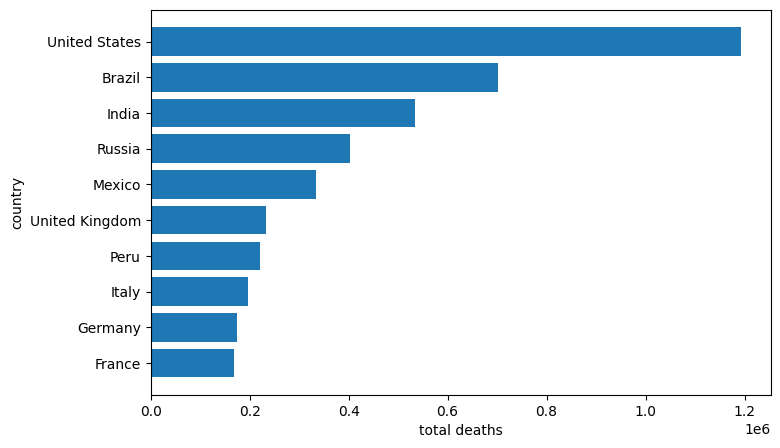

In [47]:
# Ranking Mortes
top10_totaldeaths = df_countries.groupby("location")['total_deaths'].max().reset_index().sort_values(by='total_deaths',ascending=False).head(10)
top10_totaldeathsmillion = df_countries.groupby("location")['total_deaths_per_million'].max().reset_index().sort_values(by='total_deaths_per_million',ascending=False).head(10)


plt.figure(figsize=(8,5))

plt.barh(
    top10_totaldeaths['location'],
    top10_totaldeaths['total_deaths']
)

plt.xlabel('total deaths')
plt.ylabel('country')

plt.gca().invert_yaxis()

plt.show()

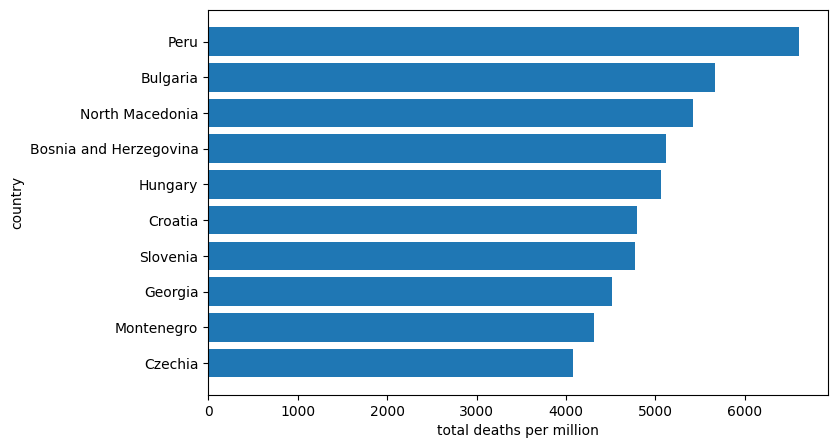

In [48]:
plt.figure(figsize=(8,5))

plt.barh(
    top10_totaldeathsmillion['location'],
    top10_totaldeathsmillion['total_deaths_per_million']
)

plt.xlabel('total deaths per million')
plt.ylabel('country')

plt.gca().invert_yaxis()

plt.show()

In [49]:
# Taxa de mortalidade por país

last_date = df.groupby('location')['date'].max().reset_index()
df_last = df.merge(
    last_date,
    on=['location', 'date'],
    how='inner'
)

df_last = df_last[df_last['total_cases'] > 0]


df_last['case_fatality_rate'] = (
    df_last['total_deaths'] / df_last['total_cases']
) * 100

top_cfr = (
    df_last
    .sort_values('case_fatality_rate', ascending=False)
    .head(10)
)

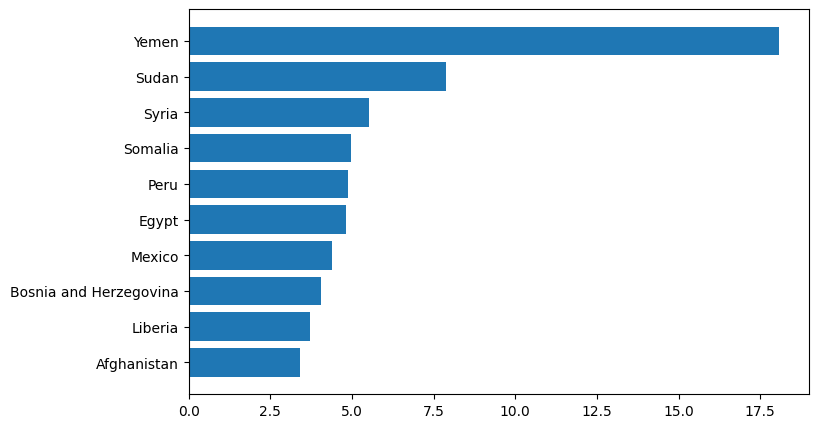

In [50]:
plt.figure(figsize=(8,5))
plt.barh(
    top_cfr['location'],
    top_cfr['case_fatality_rate']
)
plt.gca().invert_yaxis()
plt.show()

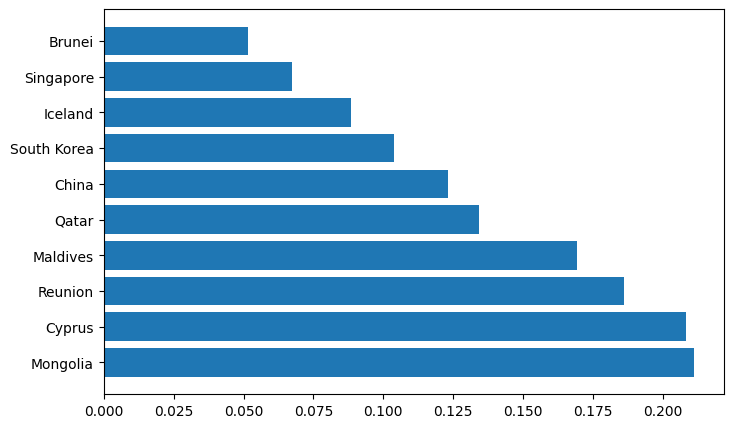

In [51]:
low_cfr = (
    df_last[
        df_last['total_cases'] > 100_000
    ]
    .sort_values('case_fatality_rate', ascending=True)
    .head(10)
)
plt.figure(figsize=(8,5))
plt.barh(
    low_cfr['location'],
    low_cfr['case_fatality_rate']
)
plt.gca().invert_yaxis()
plt.show()

In [52]:
# Vacinação por país
df_vax = (
    df_countries
    .groupby('location')
    .last()
    .reset_index()
)
df_vax = df_vax[df_vax['people_fully_vaccinated_per_hundred'] > 0]

top_vax = (
    df_vax
    .sort_values('people_fully_vaccinated_per_hundred', ascending=False)
    .head(10)
)



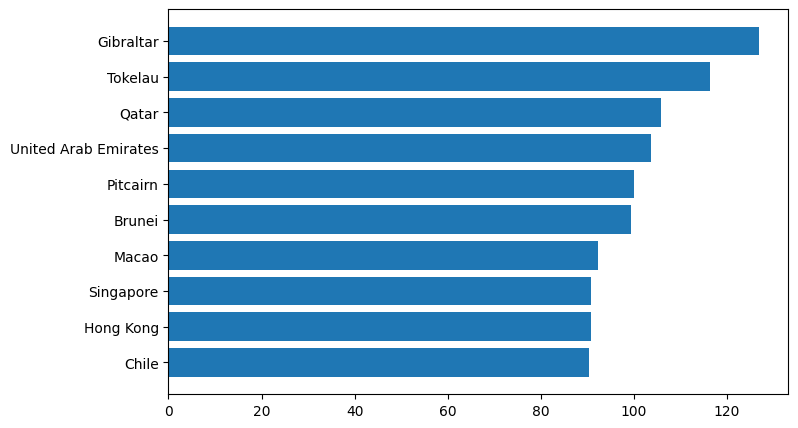

In [53]:
plt.figure(figsize=(8,5))
plt.barh(
    top_vax['location'],
    top_vax['people_fully_vaccinated_per_hundred']
)
plt.gca().invert_yaxis()
plt.show()

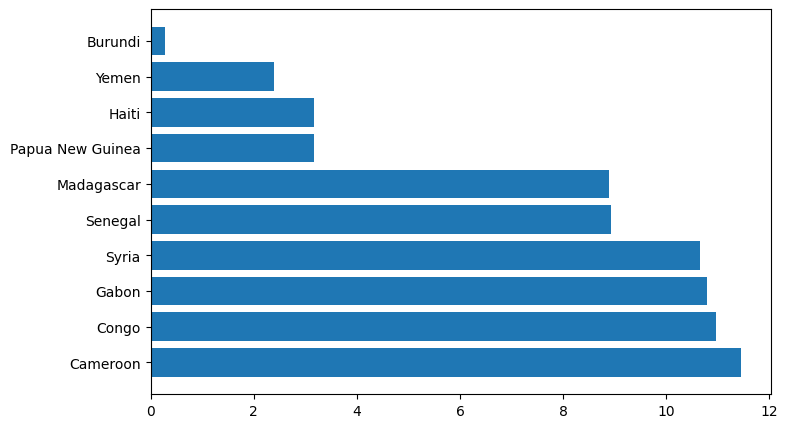

In [54]:
low_vax = (
    df_vax[
        df_vax['people_fully_vaccinated_per_hundred'] > 0
    ]
    .sort_values('people_fully_vaccinated_per_hundred', ascending=True)
    .head(10)
)

plt.figure(figsize=(8,5))
plt.barh(
    low_vax['location'],
    low_vax['people_fully_vaccinated_per_hundred']
)
plt.gca().invert_yaxis()
plt.show()

In [55]:
# Análise Temporal

In [56]:
df_world = df[df['location'] == 'World']

df_world.groupby("location")['new_cases'].sum()

location
World    775935057.0
Name: new_cases, dtype: float64

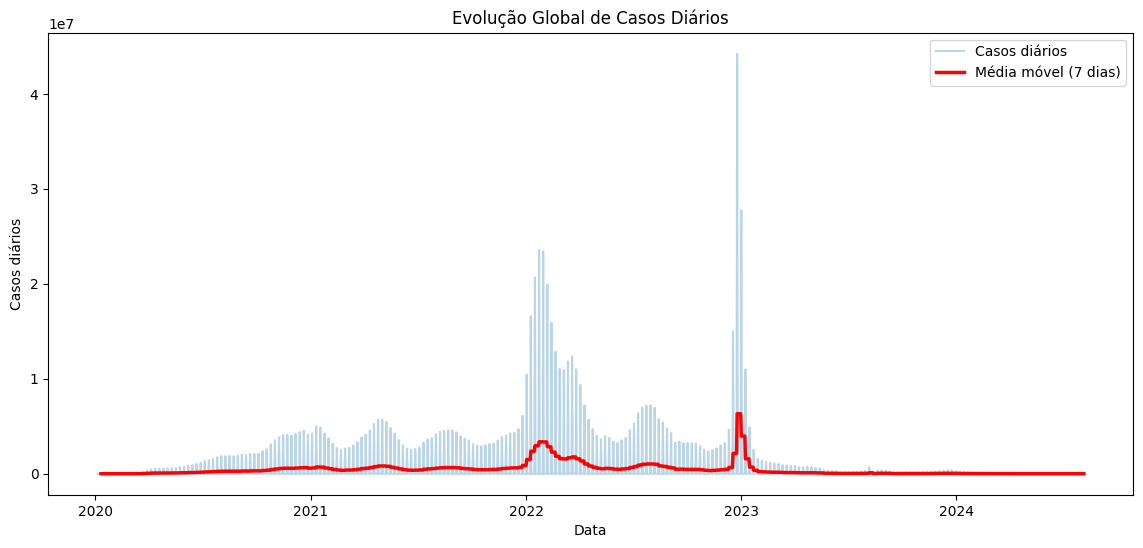

In [57]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=df_world,
    x = "date",
    y = 'new_cases',
    alpha=0.3,
    label="Casos diários"
)
sns.lineplot(
    data=df_world,
    x="date",
    y="new_cases_ma7",
    linewidth=2.5,
    color="red",
    label="Média móvel (7 dias)"
)


plt.title("Evolução Global de Casos Diários")
plt.xlabel("Data")
plt.ylabel("Casos diários")
plt.show()

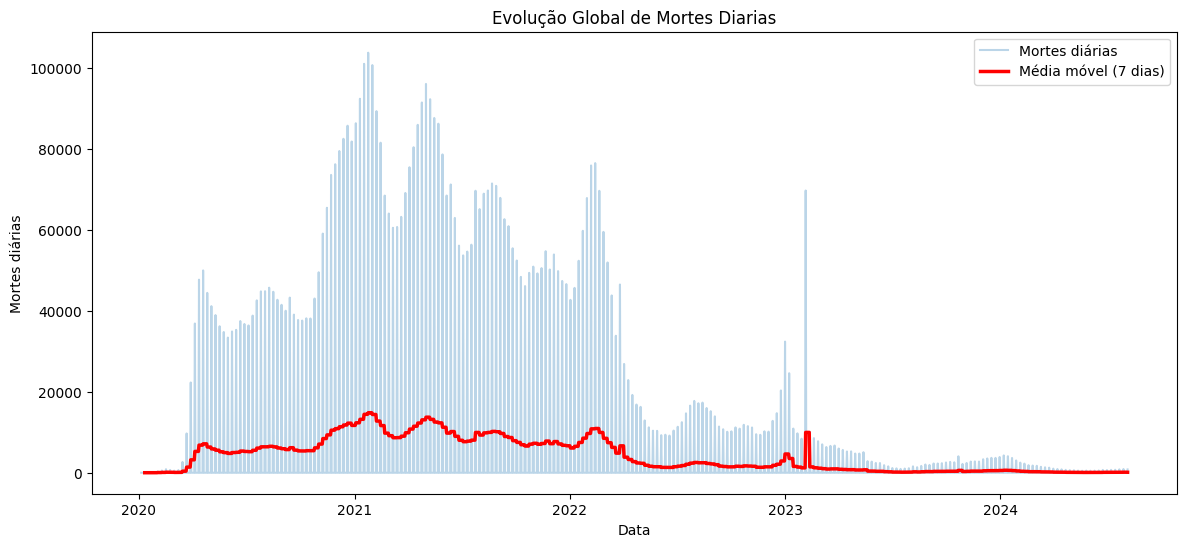

In [58]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=df_world,
    x = "date",
    y = 'new_deaths',
    alpha=0.3,
    label="Mortes diárias"
)

# Média móvel (destaque)
sns.lineplot(
    data=df_world,
    x="date",
    y="new_deaths_ma7",
    linewidth=2.5,
    color="red",
    label="Média móvel (7 dias)"
)


plt.title("Evolução Global de Mortes Diarias")
plt.xlabel("Data")
plt.ylabel("Mortes diárias")
plt.show()

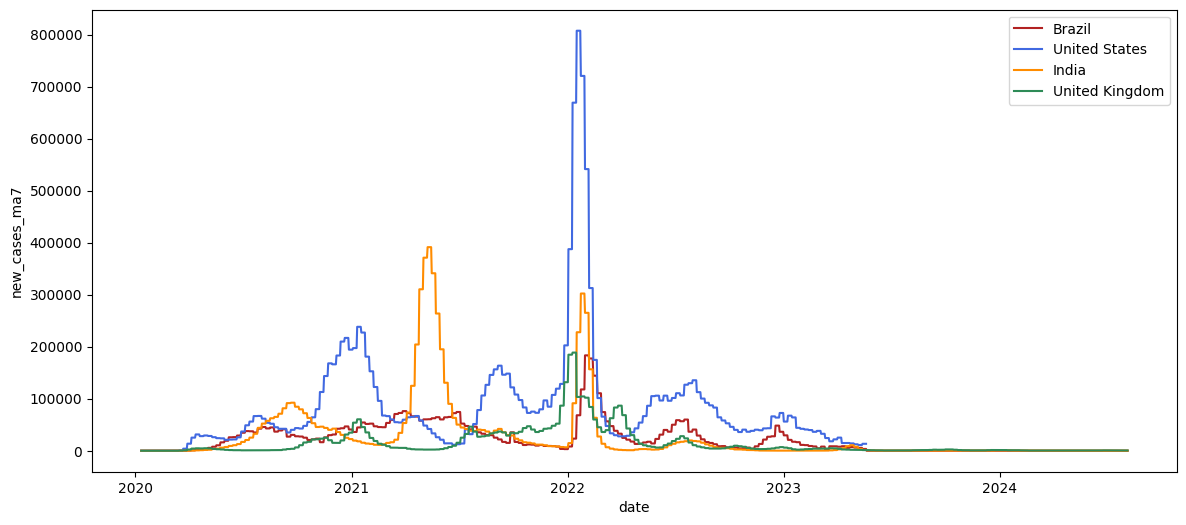

In [59]:
paises = {
    'Brazil': 'firebrick',
    'United States': 'royalblue',
    'India': 'darkorange',
    'United Kingdom': 'seagreen'
}

plt.figure(figsize=(14,6))

for pais, cor in paises.items():
    sns.lineplot(
        data=df[df['location'] == pais],
        x='date',
        y='new_cases_ma7',
        label=pais,
        color=cor,
    )

plt.show()


In [60]:
df_start = df[df['total_cases'] > 0]

day0 = (df_start.groupby('location')['date']
    .min()
    .reset_index()
    .rename(columns={'date': 'day0'})
)

df_aligned = df.merge(day0, on='location', how='inner')


df_aligned['day_number'] = (
    df_aligned['date'] - df_aligned['day0']
).dt.days


df_100 = df_aligned[
    (df_aligned['day_number'] >= 0) &
    (df_aligned['day_number'] <= 100)
]



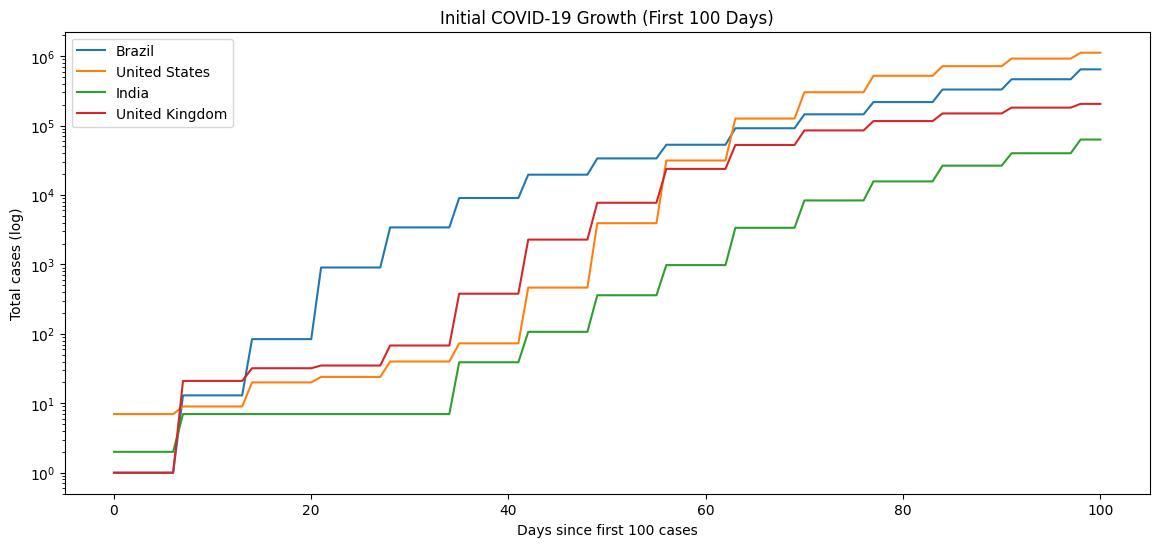

In [61]:
plt.figure(figsize=(14,6))
for pais in paises:
    sns.lineplot(
        data=df_100[df_100['location'] == pais],
        x='day_number',
        y='total_cases',
        label=pais
    )

plt.yscale('log')
plt.xlabel('Days since first 100 cases')
plt.ylabel('Total cases (log)')
plt.title('Initial COVID-19 Growth (First 100 Days)')
plt.legend()
plt.show()


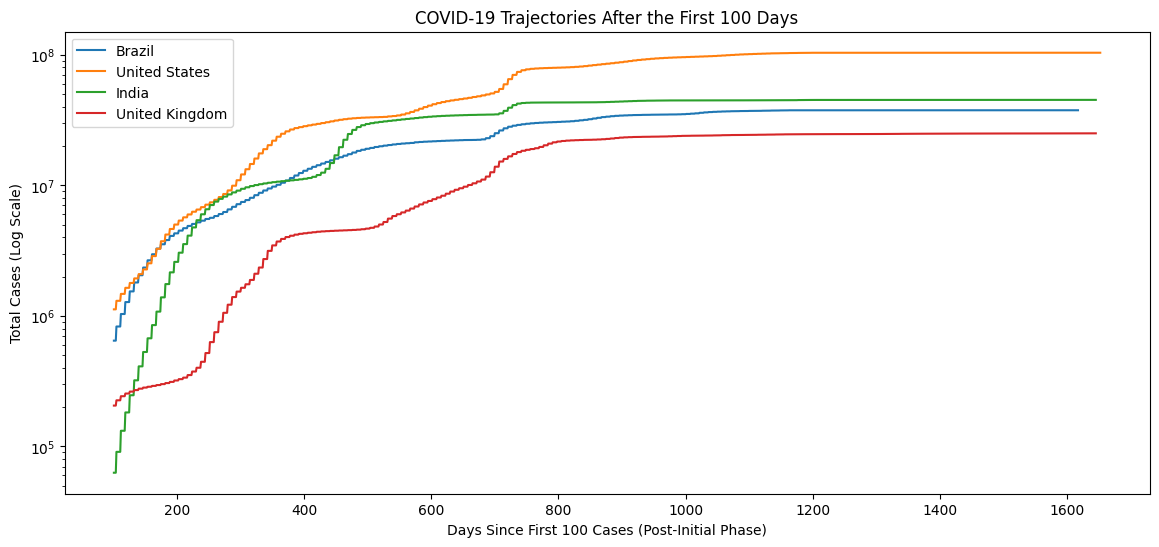

In [62]:
df_af100 = df_aligned[(df_aligned['day_number'] > 100)]

plt.figure(figsize=(14,6))
for pais in paises:
    sns.lineplot(
        data=df_af100[df_af100['location'] == pais],
        x='day_number',
        y='total_cases',
        label=pais
    )

plt.yscale('log')
plt.xlabel('Days Since First 100 Cases (Post-Initial Phase)')
plt.ylabel('Total Cases (Log Scale)')
plt.title('COVID-19 Trajectories After the First 100 Days')
plt.legend()
plt.show()

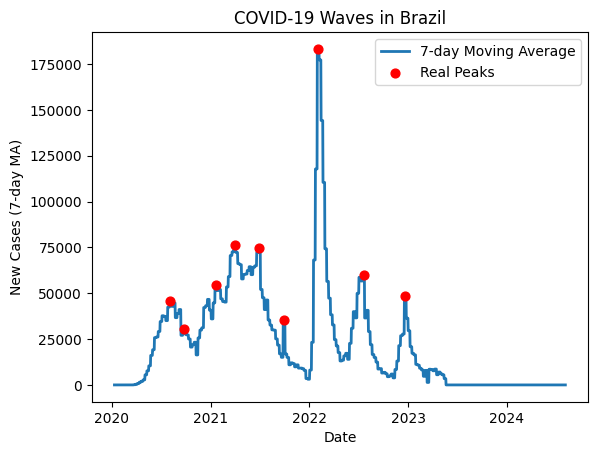

In [63]:
df_peaks=df_br[df_br["is_real_peak"] == 1]
## df_us=df[df['location'] == 'United States']

sns.lineplot(
    data=df_br,
    x='date',
    y='new_cases_ma7',
    label='7-day Moving Average',
    linewidth=2
)

plt.scatter(
    df_peaks['date'],
    df_peaks['new_cases_ma7'],
    color='red',
    s=40,
    zorder=5,
    label='Real Peaks'
)

plt.title('COVID-19 Waves in Brazil')
plt.xlabel('Date')
plt.ylabel('New Cases (7-day MA)')
plt.legend()
plt.show()

In [64]:
df_peaks['date'].dt.strftime('%y-%d-%b')

50447    20-05-Aug
50496    20-23-Sep
50615    21-20-Jan
50685    21-31-Mar
50776    21-30-Jun
50867    21-29-Sep
50993    22-02-Feb
51161    22-20-Jul
51315    22-21-Dec
Name: date, dtype: object

In [65]:
waves_duration = (
    df_br[df_br['wave_id'] > 0 ].groupby('wave_id').agg(start_date=('date','min'),end_date=('date','max')).reset_index()
)
waves_duration['duration_days'] = (
    waves_duration['end_date'] - waves_duration['start_date']).dt.days

waves_duration

,wave_id,start_date,end_date,duration_days
0,1,2020-08-05,2020-09-22,48
1,2,2020-09-23,2021-01-19,118
2,3,2021-01-20,2021-03-30,69
3,4,2021-03-31,2021-06-29,90
4,5,2021-06-30,2021-09-28,90
5,6,2021-09-29,2022-02-01,125
6,7,2022-02-02,2022-07-19,167
7,8,2022-07-20,2022-12-20,153
8,9,2022-12-21,2024-08-04,592


In [66]:
vax_diff = (df_countries['vax_start_date'].max()- df_countries['vax_start_date'].min()
).days
vax_diff

KeyError: 'vax_start_date'

In [ ]:
min_vax = df_countries.groupby("location")['vax_start_date'].min().reset_index().sort_values(by='vax_start_date')
min_vax

In [ ]:
df_countries.groupby(
    "income_category", observed=True
)['case_fatality_rate'].median().reset_index()


In [ ]:
df_country_level = (
    df_countries
    .groupby(['location', 'income_category', 'gdp_per_capita'], observed=True)
    ['case_fatality_rate']
    .median()
    .reset_index()
)

sns.scatterplot(
    data=df_country_level,
    x='gdp_per_capita',
    y='case_fatality_rate',
    hue='income_category',
    alpha=0.7
)
plt.show()



In [ ]:
df_country_density = (
    df_countries
    .groupby(['location', 'density_category', 'population_density'], observed=True)
    ['total_cases_per_million']
    .median()
    .reset_index()
)

sns.scatterplot(
    data=df_country_density,
    x='population_density',
    y='total_cases_per_million',
    hue='density_category',
    alpha=0.7
)
plt.xscale('log')
plt.show()

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_country_density,
    x='density_category',
    y='total_cases_per_million'
)
plt.show()

In [ ]:
df_age = (
    df_countries
    .groupby(['location', 'median_age'], observed=True)
    ['case_fatality_rate']
    .median()
    .reset_index()
)

In [ ]:
sns.scatterplot(
    data=df_age,
    x='median_age',
    y='case_fatality_rate',
    alpha=0.7
)

plt.show()


In [ ]:
df_age[['median_age', 'case_fatality_rate']].corr(method='spearman')

In [ ]:
df_tests = (
    df_countries
    .groupby('location', observed=True)[
        ['total_tests_per_thousand', 'case_fatality_rate']
    ]
    .median()
    .reset_index()
)


In [ ]:
sns.scatterplot(
    data=df_tests,
    x='total_tests_per_thousand',
    y='case_fatality_rate',
    alpha=0.7
)

plt.xscale('log')
plt.show()


In [ ]:
df_tests[['total_tests_per_thousand', 'case_fatality_rate']].corr(method='spearman')

In [ ]:
df_multi = (
    df_countries
    .groupby('location', observed=True)[[
        'case_fatality_rate',
        'gdp_per_capita',
        'median_age',
        'population_density',
        'total_tests_per_thousand'
    ]]
    .median()
)

corr_matrix = df_multi.corr(method='spearman')
corr_matrix


In [ ]:
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.show()


In [ ]:
df_cfr = df_countries.groupby('location')['case_fatality_rate'].median().reset_index()
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_cfr,
    x='case_fatality_rate'
)
plt.show()

In [ ]:
df_vax = df_countries.groupby('location')['people_fully_vaccinated_per_hundred'].median().reset_index()
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_vax,
    x='people_fully_vaccinated_per_hundred',
    bins=20,
    kde=True
)
plt.show()

In [ ]:
df_anova = df.groupby(['location','continent'])['case_fatality_rate'].median().reset_index().dropna()
df_anova

In [ ]:
df_anova.groupby("continent")["case_fatality_rate"]
groups = [
    group["case_fatality_rate"].values
    for name, group in df_anova.groupby("continent")
]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

In [ ]:
# Curva Global de Casos (linha + média móvel 7d)

df_global = df.groupby('date')['new_cases'].sum().reset_index()
df_global['ma7'] = df_global['new_cases'].rolling(7).mean()

plt.figure(figsize=(12,6))
sns.lineplot(data=df_global, x = 'date', y='new_cases', label = 'casos diarios')
sns.lineplot(data=df_global, x='date',y='ma7',label = 'Media movel 7d', linewidth=2.5)

plt.title("Curva Global de Casos COVID-19")
plt.xlabel("Data")
plt.ylabel("Novos Casos")
plt.xticks(rotation=45)
plt.legend()

plt.show()

In [ ]:
# Curva Global de Mortes (linha + média móvel 7d)

df_global = df.groupby('date')['new_deaths'].sum().reset_index()
df_global['ma7'] = df_global['new_deaths'].rolling(7).mean()

plt.figure(figsize=(12,6))

sns.lineplot(data=df_global, x='date', y='new_deaths', label='Mortes diárias')
sns.lineplot(data=df_global, x='date', y='ma7', label='Média móvel 7d', linewidth=2.5)

plt.title("Curva Global de Mortes COVID-19")
plt.xlabel("Data")
plt.ylabel("Novas Mortes")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Top 10 países - Casos Totais (barras horizontais)
plt.figure(figsize=(15,8))


dftop10 = (df_countries.groupby("location")['total_cases'].max().reset_index().sort_values(by='total_cases', ascending=False).head(10))
sns.barplot(
    data=dftop10,
    x='total_cases',
    y='location'
)

plt.title("Top 10 Countries - Total COVID-19 Cases")
plt.xlabel("Total Cases")
plt.ylabel("Countries")

plt.tight_layout()
plt.show()

In [ ]:
# Top 10 países - Mortes por milhão

dftop10 = df_countries.groupby('location')['total_deaths_per_million'].max().reset_index().sort_values(by='total_deaths_per_million',ascending=False).head(10)

sns.barplot(
    data=dftop10,
    x='total_deaths_per_million',
    y='location'
)

plt.title("Top 10 Countries - Deaths per Million")
plt.xlabel("Deaths per Million")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [ ]:
# PIB vs CFR

df_gdpvscrf = df_countries.groupby(['location','gdp_per_capita','income_category'], observed=True)['case_fatality_rate'].median().reset_index()

sns.lmplot(
    data=df_gdpvscrf,
    x='gdp_per_capita',
    y='case_fatality_rate',
    hue='income_category',
    logx=True,
    height=6,
    aspect=1.5

)
plt.xscale('log')
plt.show()

In [ ]:
df_gdpvscrf[['gdp_per_capita','case_fatality_rate']].corr(method='pearson')


In [ ]:
df_countries['year_month'] = df_countries['date'].dt.strftime("%Y-%m")
df['year_month'] = df['date'].dt.strftime("%Y-%m")
df_agg['year_month'] = df_agg['date'].dt.strftime("%Y-%m")
df_countries.groupby(['location','year_month'])['new_cases'].sum().reset_index()

heatmap_df = (
    df_countries.groupby(['location','year_month'])['new_cases'].sum().reset_index().pivot(index = 'location', columns = 'year_month', values = 'new_cases'))

heatmap_df

In [ ]:
top = heatmap_df.sum(axis=1).nlargest(20).index

sns.heatmap(
    heatmap_df.loc[top],
    norm=LogNorm()
)

In [ ]:
latest = df_countries.sort_values('date').groupby('location').last().reset_index()
map_df = latest[['location','iso_code', "total_cases_per_million"]]

map_df = map_df[map_df['iso_code'].str.len() == 3 ]
map_df = map_df.dropna(subset=["total_cases_per_million"])

In [ ]:
pio.renderers.default = "notebook"

latest = df_countries.sort_values("date").groupby("location").last().reset_index()

map_df = latest[["location","iso_code","total_cases_per_million"]]

map_df = map_df[~map_df["iso_code"].str.contains("OWID")]
map_df = map_df.dropna(subset=["total_cases_per_million"])


fig = px.choropleth(
    map_df,
    locations="iso_code",
    color="total_cases_per_million",
    hover_name="location",
    color_continuous_scale="Reds"
)
fig.show()

In [ ]:
import sqlite3
conn = sqlite3.connect("covid_data.db")
df.to_sql("df", conn, if_exists="replace", index=False)
df_countries.to_sql("df_countries", conn, if_exists="replace", index=False)
df_agg.to_sql("df_agg", conn, if_exists="replace", index=False)

In [ ]:
#Somar casos e mortes de todos os países

conn = sqlite3.connect('covid_data.db')

query ='''
SELECT
    location,
    SUM(total_cases) as "sum cases",
    SUM(total_deaths) as "sum deaths"
FROM df_countries
WHERE date = (
    SELECT MAX(DATE)
    FROM df_countries
    WHERE total_cases IS NOT NULL
)
group by "location"
order by "sum cases" DESC
'''

df_resultado = pd.read_sql(query,conn)
df_resultado

In [ ]:
# Top 10 países - casos
query = '''
SELECT
    location,
    total_cases
FROM df_countries
WHERE date = (
   SELECT MAX(DATE)
   FROM df_countries
   WHERE total_cases IS NOT NULL
)
ORDER BY "total_cases" DESC
LIMIT 10
'''

df_resultado = pd.read_sql(query,conn)
df_resultado

In [ ]:
# Top 10 países - mortes por milhão

query = '''
SELECT
    location,
    MAX(total_deaths_per_million)
FROM df_countries
GROUP BY location
ORDER BY "total_deaths_per_million" DESC
LIMIT 10
'''

df_resultado = pd.read_sql(query,conn)
df_resultado

In [ ]:
# Casos por agg

query = '''
SELECT
    location,
    MAX(total_cases) as max_cases
FROM df_agg
group by "location"
order by "sum_cases"
'''
df_resultado = pd.read_sql(query,conn)
df_resultado


In [ ]:
# Brasil - evolução mensal 2020
query = '''
SELECT 
    month, 
    SUM(new_cases) as total_cases
FROM df_countries
WHERE location = 'Brazil' 
  AND year = 2020
GROUP BY month
ORDER BY CAST(month AS INT)
'''

df_evolucao_brasil = pd.read_sql(query, conn)
df_evolucao_brasil


In [ ]:
# Taxa de mortalidade por país

query = '''
SELECT
    location,
    (MAX(total_deaths) * 100.0 / NULLIF(MAX(total_cases),0)) as case_fatality_rate
FROM df_countries
GROUP BY location
HAVING MAX(total_cases) > 1000
ORDER BY case_fatality_rate DESC
LIMIT 20;
'''
df_resultado = pd.read_sql(query,conn)
df_resultado


In [ ]:
# Calcular % população vacinada

query = '''
SELECT
    location,
    (max(people_fully_vaccinated) / MAX(population)) * 100 as percent_vax
FROM df_countries
GROUP BY location
ORDER BY percent_vax DESC
LIMIT 10;
'''
df_resultado = pd.read_sql(query,conn)
df_resultado

In [ ]:
# Comparação Brasil vs Argentina Casos, mortes, vacinação

query = '''
SELECT
    location,
    max(total_cases_per_million) as total_cases,
    max(total_deaths_per_million) as total_deaths,
    max(people_fully_vaccinated) as people_vax
FROM df_countries
WHERE location IN ("Brazil","Argentina")
GROUP BY location
ORDER BY total_cases ASC
'''
df_resultado = pd.read_sql(query,conn)
df_resultado

In [ ]:
# Pico de casos por país

query = '''
SELECT
    t.location,
    t.date,
    t.new_cases AS peak_cases
FROM df_countries t
JOIN (
    SELECT
        location,
        MAX(new_cases) AS peak_cases
    FROM df_countries
    GROUP BY location
) m
ON t.location = m.location
AND t.new_cases = m.peak_cases
ORDER BY peak_cases DESC;
'''
df_resultado = pd.read_sql(query,conn)
df_resultado

In [ ]:
#  Timeline de vacinação
query = '''
SELECT
    location,
    MIN(date) AS first_vaccination_date
FROM df_countries
WHERE people_vaccinated > 0
GROUP BY location
ORDER BY first_vaccination_date;
'''
df_resultado = pd.read_sql(query,conn)
df_resultado


In [ ]:
query = '''
SELECT
    date,
    new_cases,
    ROUND(
        AVG(new_cases) OVER (
            ORDER BY date
            ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
        ),
    2) AS moving_avg_7_days
FROM df_agg
WHERE location = 'World'
ORDER BY date;
'''
df_resultado = pd.read_sql(query,conn)
df_resultado

In [242]:
# df['date'] = pd.to_datetime(df['date']).dt.strftime('%Y-%m-%d')
# df_countries['date'] = pd.to_datetime(df_countries['date']).dt.strftime('%Y-%m-%d')
# df_agg['date'] = pd.to_datetime(df_agg['date']).dt.strftime('%Y-%m-%d')

# df.to_csv('df_clean.csv', sep=';', decimal=',', index=False)
# df_countries.to_csv('df_countries_clean.csv', sep=';', decimal=',', index=False)
# df_agg.to_csv('df_agg_clean.csv', sep=';', decimal=',', index=False)

In [234]:
df_countries.isnull().sum()

iso_code                                           0
continent                                          0
location                                           0
date                                               0
total_cases                                    11194
new_cases                                      12839
new_cases_smoothed                             14009
total_deaths                                   11194
new_deaths                                     12390
new_deaths_smoothed                            13560
total_cases_per_million                        11194
new_cases_per_million                          12839
new_cases_smoothed_per_million                 14009
total_deaths_per_million                       11194
new_deaths_per_million                         12390
new_deaths_smoothed_per_million                13560
reproduction_rate                             219169
icu_patients                                  363794
icu_patients_per_million                      

In [240]:
df_agg.groupby('location')["total_cases"].max().reset_index()

,location,total_cases
0,Africa,13145380.0
1,Asia,301499099.0
2,Europe,252916868.0
3,European Union (27),185822587.0
4,High-income countries,429044049.0
5,Low-income countries,1944334.0
6,Lower-middle-income countries,91954400.0
7,North America,124492666.0
8,Oceania,15003352.0
9,South America,68809418.0


In [74]:
def analyze_covid_data(df, df_countries, df_agg):
    """
    Analisa os dados de COVID-19 e gera insights estruturados
    """
    
    insights = {
        "metadata": {},
        "temporal_patterns": {},
        "geographic_insights": {},
        "vaccination_analysis": {},
        "waves_and_peaks": {},
        "epidemiological_metrics": {},
        "correlations": {},
        "anomalies": {},
        "top_performers": {},
        "trends": {}
    }
    
    # ========== METADATA ==========
    insights["metadata"] = {
        "total_records": len(df),
        "countries_count": df_countries['location'].nunique() if 'location' in df_countries.columns else 0,
        "date_range": {
            "start": str(df['date'].min()),
            "end": str(df['date'].max()),
            "days_covered": (pd.to_datetime(df['date'].max()) - pd.to_datetime(df['date'].min())).days
        },
        "continents": df['continent'].dropna().unique().tolist() if 'continent' in df.columns else [],
        "data_completeness": {
            col: float(1 - df[col].isna().sum() / len(df)) 
            for col in ['total_cases', 'total_deaths', 'total_vaccinations', 'new_cases', 'new_deaths']
            if col in df.columns
        }
    }
    
    # ========== TEMPORAL PATTERNS ==========
    df_temp = df.copy()
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp['year'] = df_temp['date'].dt.year
    df_temp['month'] = df_temp['date'].dt.month
    
    # Casos por ano
    yearly_cases = df_temp.groupby('year')['new_cases'].sum().to_dict()
    yearly_deaths = df_temp.groupby('year')['new_deaths'].sum().to_dict()
    
    insights["temporal_patterns"] = {
        "yearly_cases": {str(k): float(v) if pd.notna(v) else 0 for k, v in yearly_cases.items()},
        "yearly_deaths": {str(k): float(v) if pd.notna(v) else 0 for k, v in yearly_deaths.items()},
        "peak_month": {
            "cases": int(df_temp.groupby('month')['new_cases'].sum().idxmax()) if 'new_cases' in df_temp.columns else None,
            "deaths": int(df_temp.groupby('month')['new_deaths'].sum().idxmax()) if 'new_deaths' in df_temp.columns else None
        },
        "worst_day": {
            "date": str(df_temp.loc[df_temp['new_cases'].idxmax(), 'date']) if 'new_cases' in df_temp.columns else None,
            "cases": float(df_temp['new_cases'].max()) if 'new_cases' in df_temp.columns else 0
        }
    }
    
    # ========== GEOGRAPHIC INSIGHTS ==========
    # Top países por métricas
    latest_by_country = df_countries.sort_values('date').groupby('location').tail(1) if 'location' in df_countries.columns else pd.DataFrame()
    
    top_countries_cases = latest_by_country.nlargest(10, 'total_cases')[['location', 'total_cases']].to_dict('records') if 'total_cases' in latest_by_country.columns else []
    top_countries_deaths = latest_by_country.nlargest(10, 'total_deaths')[['location', 'total_deaths']].to_dict('records') if 'total_deaths' in latest_by_country.columns else []
    top_countries_cfr = latest_by_country.nlargest(10, 'case_fatality_rate')[['location', 'case_fatality_rate']].to_dict('records') if 'case_fatality_rate' in latest_by_country.columns else []
    
    insights["geographic_insights"] = {
        "top_10_cases": [
            {"country": r['location'], "value": float(r['total_cases']) if pd.notna(r['total_cases']) else 0}
            for r in top_countries_cases
        ],
        "top_10_deaths": [
            {"country": r['location'], "value": float(r['total_deaths']) if pd.notna(r['total_deaths']) else 0}
            for r in top_countries_deaths
        ],
        "highest_cfr": [
            {"country": r['location'], "value": float(r['case_fatality_rate']) if pd.notna(r['case_fatality_rate']) else 0}
            for r in top_countries_cfr
        ],
        "by_continent": df.groupby('continent').agg({
            'total_cases': 'max',
            'total_deaths': 'max'
        }).to_dict() if 'continent' in df.columns else {}
    }
    
    # ========== VACCINATION ANALYSIS ==========
    vax_data = latest_by_country[latest_by_country['people_fully_vaccinated_per_hundred'].notna()] if 'people_fully_vaccinated_per_hundred' in latest_by_country.columns else pd.DataFrame()
    
    insights["vaccination_analysis"] = {
        "global_average_full_vax": float(vax_data['people_fully_vaccinated_per_hundred'].mean()) if len(vax_data) > 0 else 0,
        "top_vaccinated": vax_data.nlargest(10, 'people_fully_vaccinated_per_hundred')[['location', 'people_fully_vaccinated_per_hundred']].to_dict('records') if len(vax_data) > 0 else [],
        "countries_above_70pct": int((vax_data['people_fully_vaccinated_per_hundred'] >= 70).sum()) if len(vax_data) > 0 else 0,
        "avg_days_to_start_vax": float(df_countries['days_since_vax_start'].max()) if 'days_since_vax_start' in df_countries.columns else 0,
        "vaccination_speed": {
            "fastest": df_countries.nlargest(5, 'vax_speed_7d')[['location', 'vax_speed_7d']].to_dict('records') if 'vax_speed_7d' in df_countries.columns else []
        }
    }
    
    # ========== WAVES AND PEAKS ==========
    waves_data = df_countries[df_countries['wave_id'].notna()] if 'wave_id' in df_countries.columns else pd.DataFrame()
    
    insights["waves_and_peaks"] = {
        "avg_waves_per_country": float(waves_data.groupby('location')['wave_id'].max().mean()) if len(waves_data) > 0 else 0,
        "countries_most_waves": waves_data.groupby('location')['wave_id'].max().nlargest(10).to_dict() if len(waves_data) > 0 else {},
        "total_real_peaks": int(df['is_real_peak'].sum()) if 'is_real_peak' in df.columns else 0,
        "avg_peak_intensity": float(df[df['is_real_peak'] == 1]['peak_intensity'].mean()) if 'is_real_peak' in df.columns and 'peak_intensity' in df.columns else 0,
        "avg_days_between_peaks": float(df[df['is_real_peak'] == 1]['days_since_last_peak'].mean()) if 'is_real_peak' in df.columns and 'days_since_last_peak' in df.columns else 0
    }
    
    # ========== EPIDEMIOLOGICAL METRICS ==========
    insights["epidemiological_metrics"] = {
        "global_cfr": float(latest_by_country['case_fatality_rate'].mean()) if 'case_fatality_rate' in latest_by_country.columns else 0,
        "avg_reproduction_rate": float(df['reproduction_rate'].mean()) if 'reproduction_rate' in df.columns else 0,
        "peak_reproduction_rate": float(df['reproduction_rate'].max()) if 'reproduction_rate' in df.columns else 0,
        "avg_positive_rate": float(df['positive_rate'].mean() * 100) if 'positive_rate' in df.columns else 0,
        "peak_positive_rate": float(df['positive_rate'].max() * 100) if 'positive_rate' in df.columns else 0,
        "icu_utilization": {
            "max_patients": float(df['icu_patients'].max()) if 'icu_patients' in df.columns else 0,
            "avg_per_million": float(df['icu_patients_per_million'].mean()) if 'icu_patients_per_million' in df.columns else 0
        }
    }
    
    # ========== CORRELATIONS ==========
    corr_columns = ['total_cases', 'total_deaths', 'people_fully_vaccinated_per_hundred', 
                    'stringency_index', 'population_density', 'gdp_per_capita', 
                    'median_age', 'hospital_beds_per_thousand']
    available_corr_cols = [col for col in corr_columns if col in latest_by_country.columns]
    
    if len(available_corr_cols) > 1:
        corr_matrix = latest_by_country[available_corr_cols].corr()
        
        # Principais correlações
        correlations_list = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                correlations_list.append({
                    "var1": corr_matrix.columns[i],
                    "var2": corr_matrix.columns[j],
                    "correlation": float(corr_matrix.iloc[i, j])
                })
        
        correlations_list.sort(key=lambda x: abs(x['correlation']), reverse=True)
        insights["correlations"] = {
            "strongest": correlations_list[:10],
            "cases_vs_deaths": float(corr_matrix.loc['total_cases', 'total_deaths']) if 'total_cases' in corr_matrix.columns and 'total_deaths' in corr_matrix.columns else None,
            "density_vs_cases": float(corr_matrix.loc['population_density', 'total_cases']) if 'population_density' in corr_matrix.columns and 'total_cases' in corr_matrix.columns else None
        }
    
    # ========== ANOMALIES ==========
    # Países com CFR muito alto ou baixo
    cfr_data = latest_by_country[latest_by_country['case_fatality_rate'].notna()] if 'case_fatality_rate' in latest_by_country.columns else pd.DataFrame()
    
    insights["anomalies"] = {
        "extreme_cfr_high": cfr_data.nlargest(5, 'case_fatality_rate')[['location', 'case_fatality_rate']].to_dict('records') if len(cfr_data) > 0 else [],
        "extreme_cfr_low": cfr_data.nsmallest(5, 'case_fatality_rate')[['location', 'case_fatality_rate']].to_dict('records') if len(cfr_data) > 0 else [],
        "sudden_spikes": {
            "max_daily_growth": float(df['daily_growth_pct'].max()) if 'daily_growth_pct' in df.columns else 0,
            "countries_with_spikes": df[df['daily_growth_pct'] > 100].groupby('location').size().to_dict() if 'daily_growth_pct' in df.columns else {}
        }
    }
    
    # ========== TOP PERFORMERS ==========
    insights["top_performers"] = {
        "lowest_deaths_per_million": latest_by_country.nsmallest(10, 'total_deaths_per_million')[['location', 'total_deaths_per_million']].to_dict('records') if 'total_deaths_per_million' in latest_by_country.columns else [],
        "fastest_vaccination": latest_by_country.nsmallest(10, 'days_to_70pct')[['location', 'days_to_70pct']].to_dict('records') if 'days_to_70pct' in latest_by_country.columns else [],
        "best_testing": latest_by_country.nlargest(10, 'total_tests_per_thousand')[['location', 'total_tests_per_thousand']].to_dict('records') if 'total_tests_per_thousand' in latest_by_country.columns else []
    }
    
    # ========== TRENDS ==========
    # Últimos 90 dias
    recent_data = df_temp[df_temp['date'] >= df_temp['date'].max() - pd.Timedelta(days=90)]
    
    insights["trends"] = {
        "recent_90_days": {
            "total_new_cases": float(recent_data['new_cases'].sum()) if 'new_cases' in recent_data.columns else 0,
            "total_new_deaths": float(recent_data['new_deaths'].sum()) if 'new_deaths' in recent_data.columns else 0,
            "avg_daily_cases": float(recent_data['new_cases'].mean()) if 'new_cases' in recent_data.columns else 0,
            "trend": "increasing" if recent_data['new_cases'].iloc[-7:].mean() > recent_data['new_cases'].iloc[-30:-23].mean() else "decreasing" if 'new_cases' in recent_data.columns else "unknown"
        },
        "growth_rates": {
            "avg_weekly_growth": float(df['weekly_growth_rate'].mean()) if 'weekly_growth_rate' in df.columns else 0,
            "peak_weekly_growth": float(df['weekly_growth_rate'].max()) if 'weekly_growth_rate' in df.columns else 0
        }
    }
    
    # ========== INCOME & DEMOGRAPHIC ANALYSIS ==========
    if 'income_category' in latest_by_country.columns:
        income_analysis = latest_by_country.groupby('income_category').agg({
            'total_cases_per_million': 'mean',
            'total_deaths_per_million': 'mean',
            'people_fully_vaccinated_per_hundred': 'mean'
        }).to_dict()
        
        insights["demographic_patterns"] = {
            "by_income": income_analysis,
            "by_age": latest_by_country.groupby('age_category')['case_fatality_rate'].mean().to_dict() if 'age_category' in latest_by_country.columns else {},
            "by_density": latest_by_country.groupby('density_category')['total_cases_per_million'].mean().to_dict() if 'density_category' in latest_by_country.columns else {}
        }
    
    return insights


In [75]:
insights = analyze_covid_data(df, df_countries, df_agg)

In [76]:
import json

print(json.dumps(insights, indent=2))

{
  "metadata": {
    "total_records": 429435,
    "countries_count": 243,
    "date_range": {
      "start": "2020-01-01 00:00:00",
      "end": "2024-08-14 00:00:00",
      "days_covered": 1687
    },
    "continents": [
      "Asia",
      "Europe",
      "Africa",
      "Oceania",
      "North America",
      "South America"
    ],
    "data_completeness": {
      "total_cases": 0.9589437283872996,
      "total_deaths": 0.9589437283872996,
      "total_vaccinations": 0.1989055386729074,
      "new_cases": 0.9551131137424755,
      "new_deaths": 0.9561586736060173
    }
  },
  "temporal_patterns": {
    "yearly_cases": {
      "2020": 335975852.0,
      "2021": 839031625.0,
      "2022": 1821211397.0,
      "2023": 283467861.0,
      "2024": 8705598.0
    },
    "yearly_deaths": {
      "2020": 7970042.0,
      "2021": 14724578.0,
      "2022": 5285680.0,
      "2023": 1347670.0,
      "2024": 175093.0
    },
    "peak_month": {
      "cases": 1,
      "deaths": 1
    },
    "worst_